In [1]:
import sys
try:
    import pyLOM
except ImportError as e:
    print(f'Error importing pyLOM: {e}')
    print('Importing with local repository')
    sys.path.append('/home/m.jaraiz/repos/pyLowOrder/')
from FotR import FRODO, SAM

0 Warning! Import - NVTX not present!


In [2]:
db0_path = '/home/m.jaraiz/Documentos/DATASETS/data_TIFON/rans3_extended/outputs' # 100 simulaciones originales con campo fluido interpolado
db1_CODA_path = '/home/m.jaraiz/Documentos/DATASETS/data_TIFON/rans3_transonic_1' # 80 simulaciones transónicas con CADGroup 3 y 4 separados

In [3]:
db1_CODA = FRODO(root_dir = db1_CODA_path, format = 'CODA', initial_parse=True)


 NEW CODA SIMULATION WILL BE LOADED FROM /home/m.jaraiz/Documentos/DATASETS/data_TIFON/rans3_transonic_1
80 simulations found.
Parse taked: 0.0492 seconds


In [ ]:
db1_CODA.reader.print_available_cadgroup_ids(stage=0, vtu_type='surface')
db1_CODA.reader.print_available_cadgroup_ids(stage=0, vtu_type='volume')

Interpolar campo fluido y sacar .h5 pylom de zona transónica

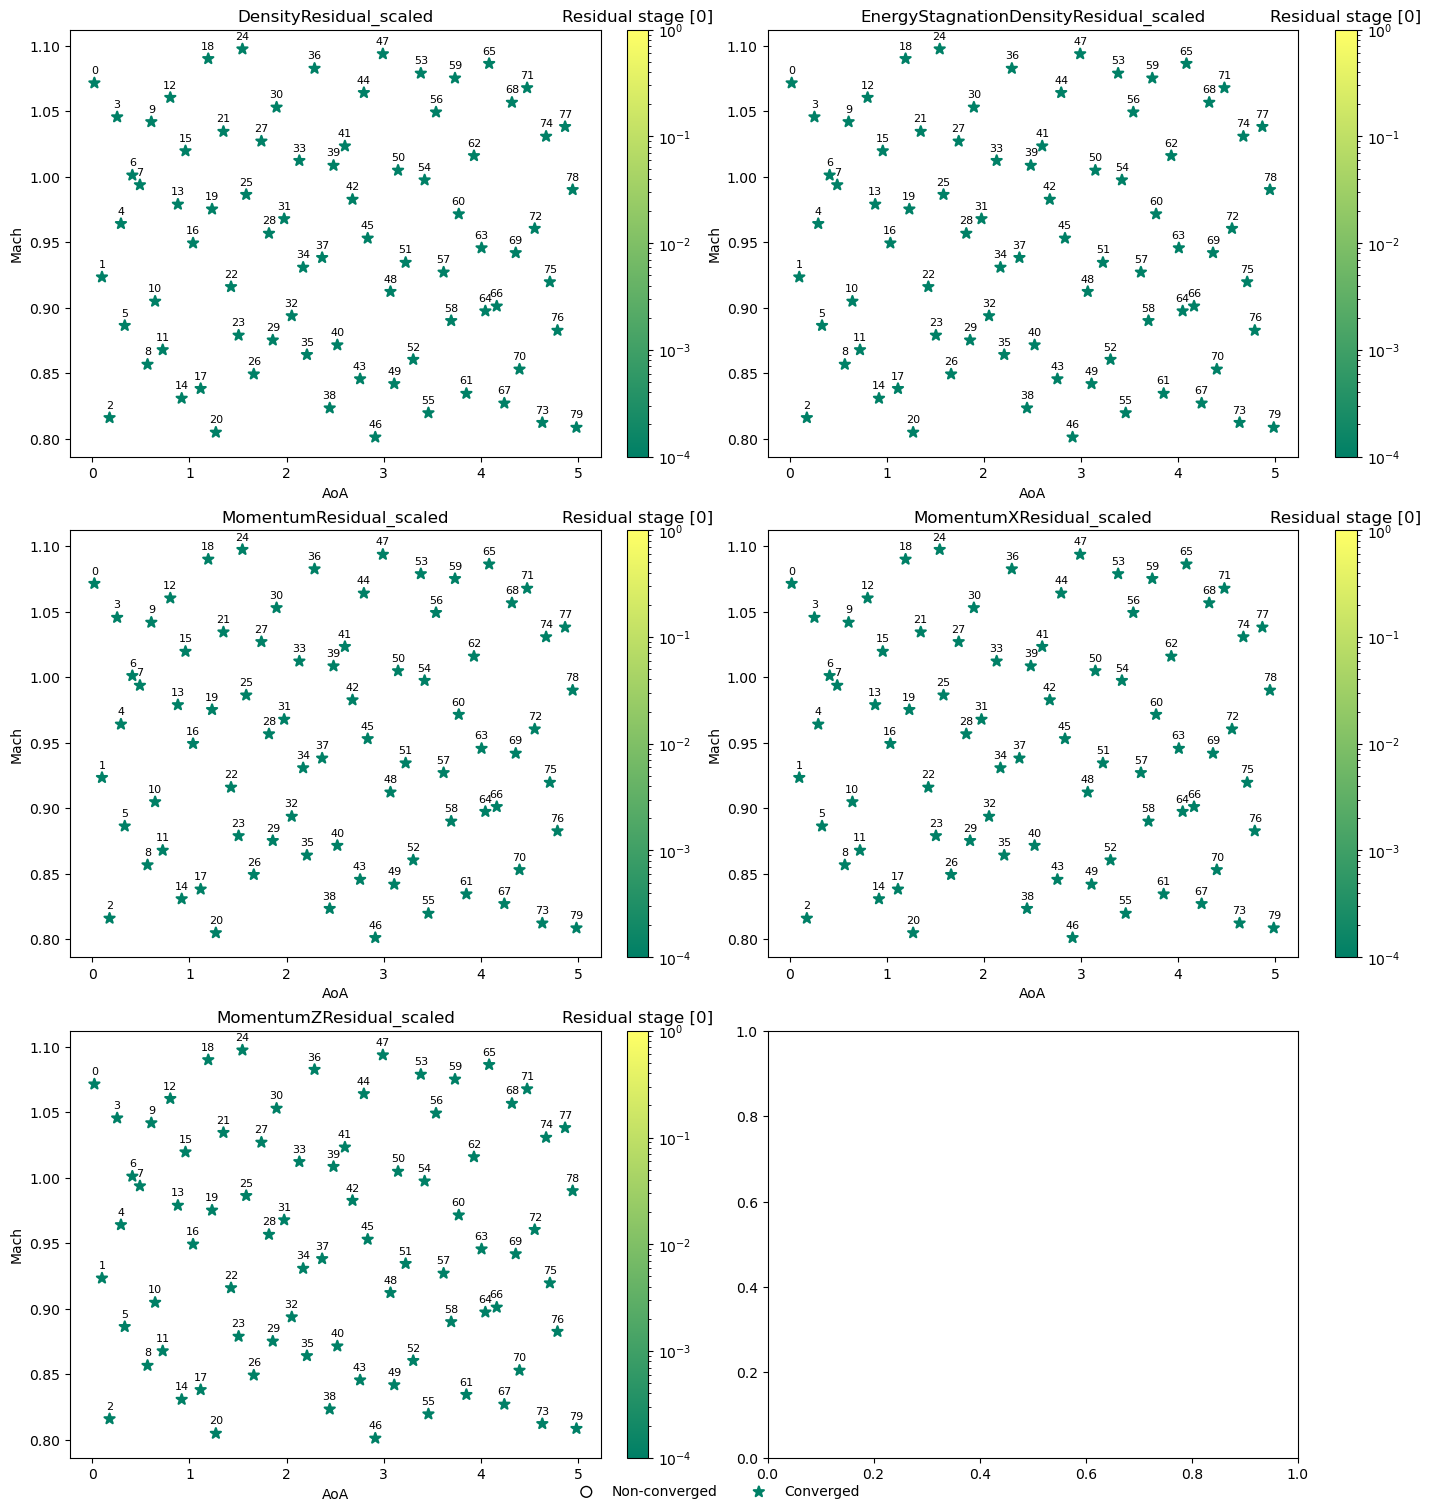

In [6]:
db1_CODA.residuals.plot_all_final_residuals(mode='scaled', stage=[0,], lim_converged=1e-4, only_finished=True, print_non_converged=False, activate_idx=True)

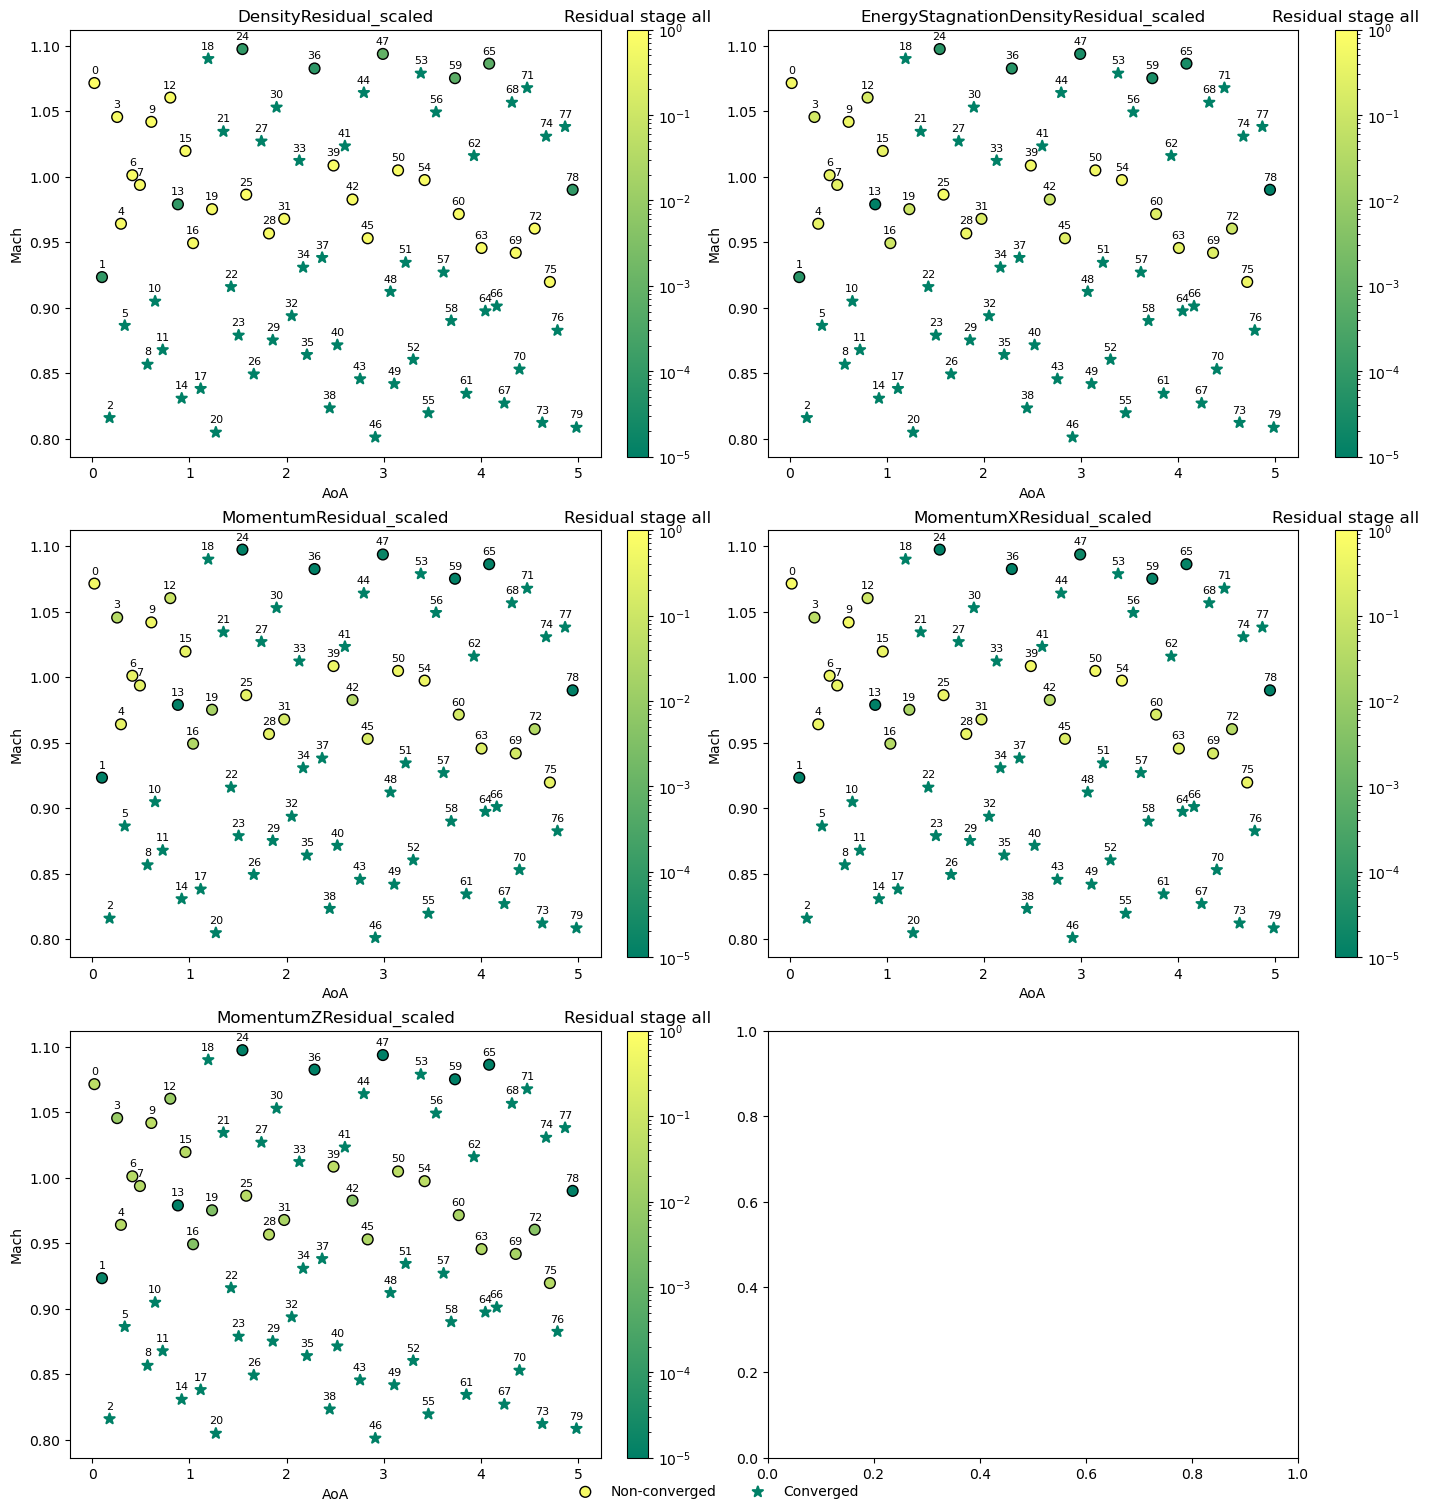

In [5]:
db1_CODA.residuals.plot_all_final_residuals(mode='scaled', stage='all', lim_converged=1e-5, only_finished=True, print_non_converged=False, activate_idx=True)

In [8]:
case_stage1 = list(range(80))
to_remove = [0, 3, 4, 6, 7, 9, 12, 15, 16, 19, 25, 28, 31, 39, 42, 45, 50, 54, 60, 63, 69, 72, 75]
for elem in to_remove:
    case_stage1.remove(elem)

db1_CODA.extract_inputs(
    id_groups = (3,),
    cases_idx = 'all',
    vtu_type='surface',
    verbose=False
    )

db1_CODA.extract_outputs(
    id_groups=(3,),
    stage=0, cases_idx = 'all',
    var_name_excluded = [
        'BoundaryValues_CoefSkinFrictionX',
        'BoundaryValues_CoefSkinFrictionY',
        'BoundaryValues_CoefSkinFrictionZ'
        ],
    vtu_type='surface',
    )

db1_CODA.extract_outputs(
    id_groups=(3,),
    stage=1, cases_idx = case_stage1,
    var_name_excluded = [
        'BoundaryValues_CoefSkinFrictionX',
        'BoundaryValues_CoefSkinFrictionY',
        'BoundaryValues_CoefSkinFrictionZ'
        ],
    vtu_type='surface',
    )

db1_CODA.summary_data()

root
└── CADGroup_3
    ├── Coord
    │   └── Numpy Array(shape=(5999, 3), dtype=float64)
    ├── NodeCoord
    │   └── Numpy Array(shape=(11998, 3), dtype=float64)
    ├── FlCc
    │   └── Numpy Array(shape=(80, 2), dtype=float64)
    ├── Conec
    │   └── Numpy Array(shape=(5999, 4), dtype=int64)
    ├── idx_sort
    │   └── Numpy Array(shape=(2, 80, 5999), dtype=int32)
    ├── idx_sort_nodes
    │   └── Numpy Array(shape=(2, 80, 11998), dtype=int32)
    ├── eltype
    │   └── Numpy Array(shape=(5999,), dtype=uint8)
    ├── cellOrder
    │   └── Numpy Array(shape=(5999,), dtype=float64)
    ├── pointOrder
    │   └── Numpy Array(shape=(11998,), dtype=float64)
    └── Vars
        ├── 0
        │   ├── GlobalNumber
        │   │   └── Numpy Array(shape=(5999, 80), dtype=float64)
        │   ├── CADGroupID
        │   │   └── Numpy Array(shape=(5999, 80), dtype=float64)
        │   ├── BoundaryValues_CoefPressure
        │   │   └── Numpy Array(shape=(5999, 80), dtype=float64)
        │   ├── BoundaryValues_CoefSkinFrictionTangential
        │   │   └── Numpy Array(shape=(5999, 80), dtype=float64)
        │   └── BoundaryValues_YPlusFirstCell
        │       └── Numpy Array(shape=(5999, 80), dtype=float64)
        └── 1
            ├── GlobalNumber
            │   └── Numpy Array(shape=(5999, 57), dtype=float64)
            ├── CADGroupID
            │   └── Numpy Array(shape=(5999, 57), dtype=float64)
            ├── BoundaryValues_CoefPressure
            │   └── Numpy Array(shape=(5999, 57), dtype=float64)
            ├── BoundaryValues_CoefSkinFrictionTangential
            │   └── Numpy Array(shape=(5999, 57), dtype=float64)
            └── BoundaryValues_YPlusFirstCell
                └── Numpy Array(shape=(5999, 57), dtype=float64)